## iris analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
df = pd.read_csv("Iris.csv")

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.tail()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
149,150,5.9,3.0,5.1,1.8,Iris-virginica


In [5]:
df.shape

(150, 6)

In [6]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [7]:
df.dtypes

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

In [11]:
df_change=[
    "SepalLengthCm",    
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]

df[df_change]=df[df_change].astype(int)
df["Species"]=df["Species"].astype("category")

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.dtypes

Id                  int64
SepalLengthCm       int64
SepalWidthCm        int64
PetalLengthCm       int64
PetalWidthCm        int64
Species          category
dtype: object

# univariate analysis

In [16]:
df["SepalLengthCm"].mean()
df["SepalLengthCm"].median()
df["SepalLengthCm"].mode()
df.max(numeric_only=True) - df.min(numeric_only=True)
df.var(numeric_only=True)
df.std(numeric_only=True)
df["SepalLengthCm"].skew()
df["SepalLengthCm"].kurtosis()

np.float64(-0.5781865600187106)

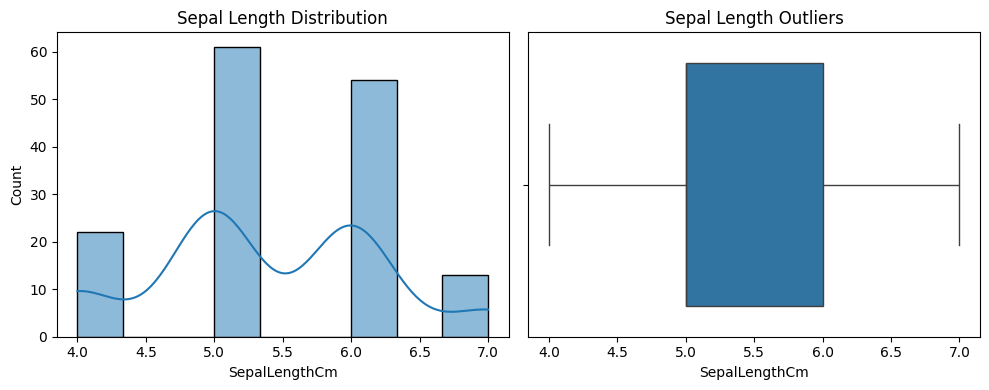

In [17]:
fig, ax = plt.subplots(1,2,figsize=(10,4))

sns.histplot(
    df["SepalLengthCm"],
    kde=True,
    ax=ax[0]
)

ax[0].set_title("Sepal Length Distribution")

sns.boxplot(
    x=df["SepalLengthCm"],
    ax=ax[1]
)

ax[1].set_title("Sepal Length Outliers")

plt.tight_layout()
plt.show()

In [18]:
df["Species"].value_counts()

df["Species"].nunique()

3

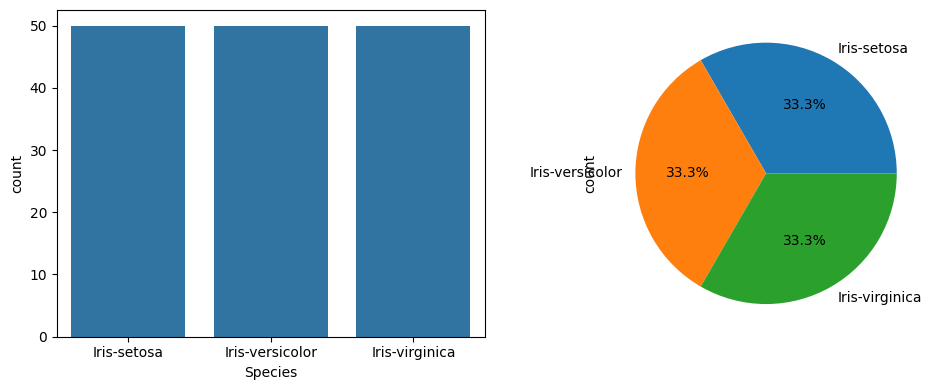

In [19]:
fig, ax = plt.subplots(1,2,figsize=(10,4))

sns.countplot(
    x=df["Species"],
    ax=ax[0]
)

df["Species"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=ax[1]
)

plt.tight_layout()
plt.show()

## BRIVETIVE

In [20]:
df[
    ["PetalLengthCm",
     "PetalWidthCm"]
].corr()

,PetalLengthCm,PetalWidthCm
PetalLengthCm,1.000000,0.908784
PetalWidthCm,0.908784,1.000000


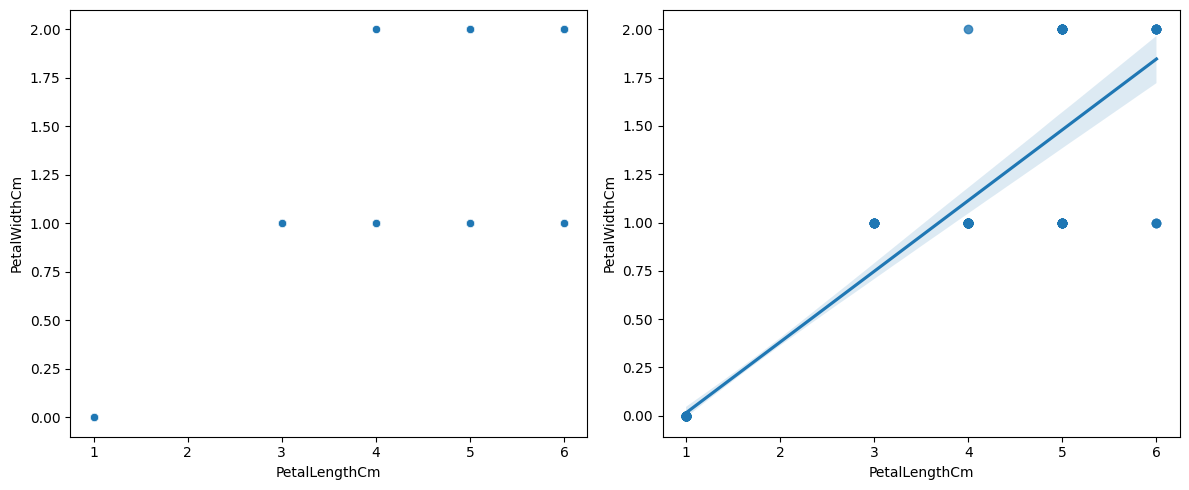

In [21]:
fig, ax = plt.subplots(1,2,figsize=(12,5))

sns.scatterplot(
    x=df["PetalLengthCm"],
    y=df["PetalWidthCm"],
    ax=ax[0]
)

sns.regplot(
    x=df["PetalLengthCm"],
    y=df["PetalWidthCm"],
    ax=ax[1]
)

plt.tight_layout()
plt.show()

In [23]:
df.groupby(
    "Species",observed=True
)["PetalLengthCm"].mean()

Species
Iris-setosa        1.00
Iris-versicolor    3.82
Iris-virginica     5.10
Name: PetalLengthCm, dtype: float64

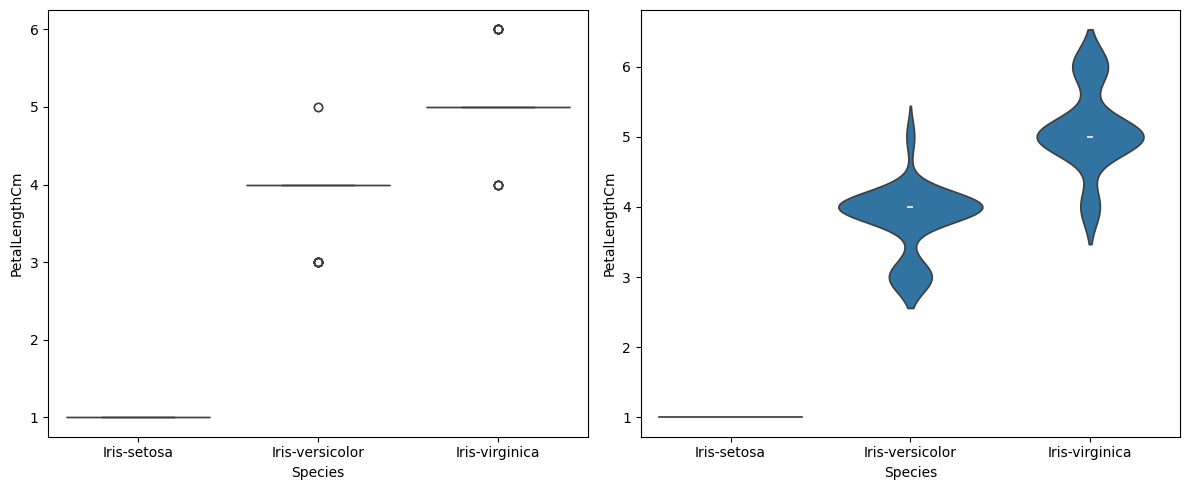

In [24]:
fig, ax = plt.subplots(1,2,figsize=(12,5))

sns.boxplot(
    x="Species",
    y="PetalLengthCm",
    data=df,
    ax=ax[0]
)

sns.violinplot(
    x="Species",
    y="PetalLengthCm",
    data=df,
    ax=ax[1]
)

plt.tight_layout()
plt.show()

## multivariate

In [25]:
corr = df.corr(
    numeric_only=True
)

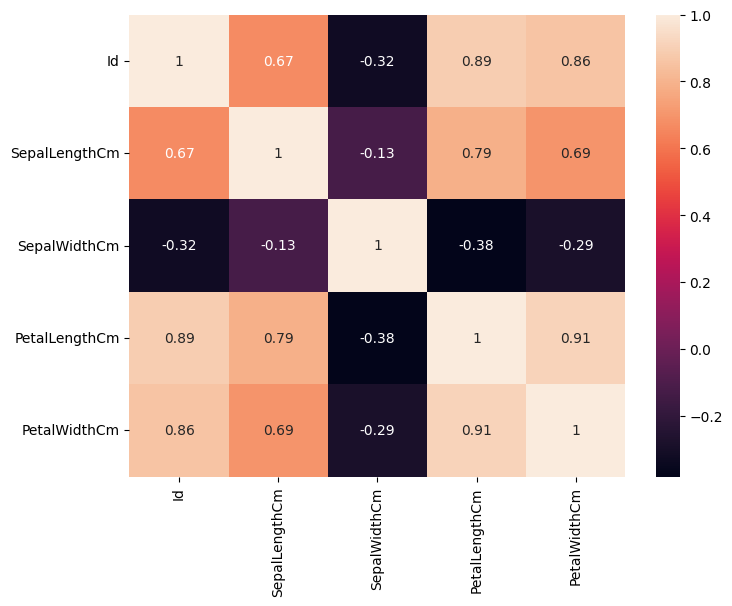

In [26]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True
)

plt.show()

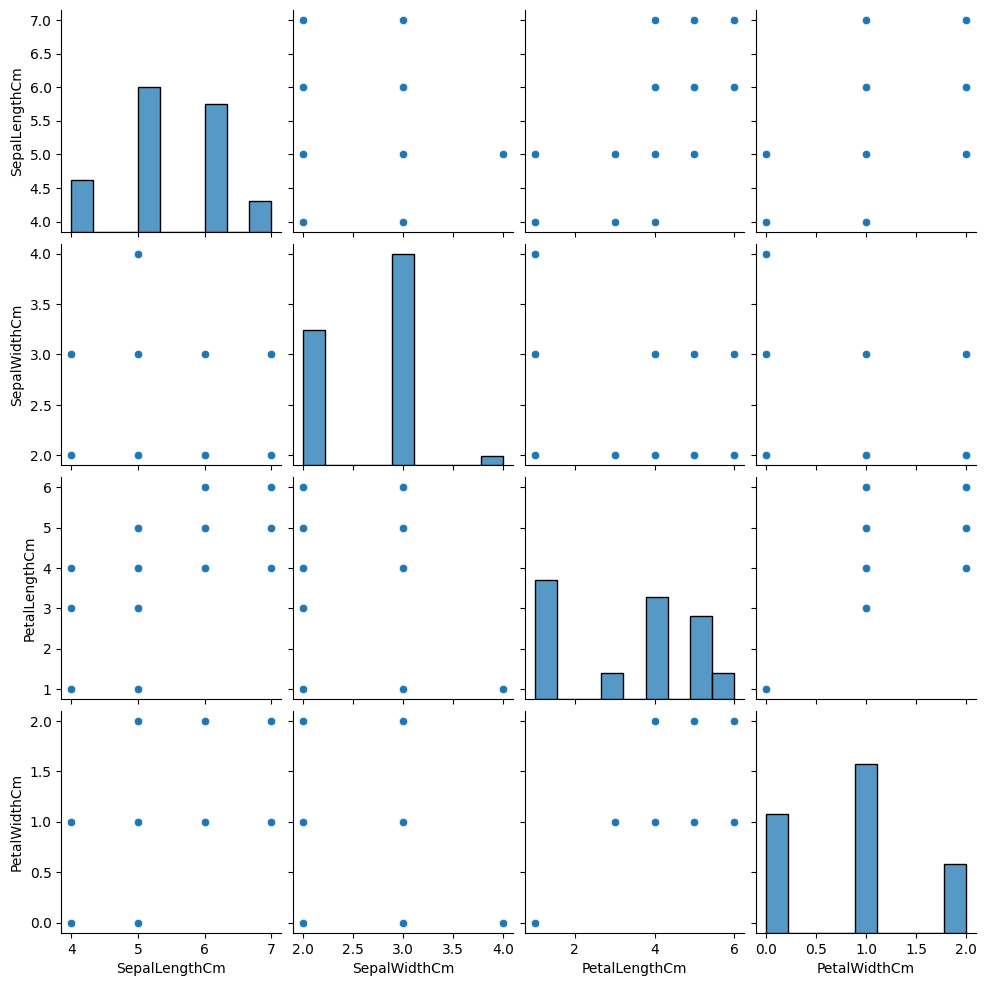

In [29]:
sns.pairplot(df[[
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]])

plt.show()

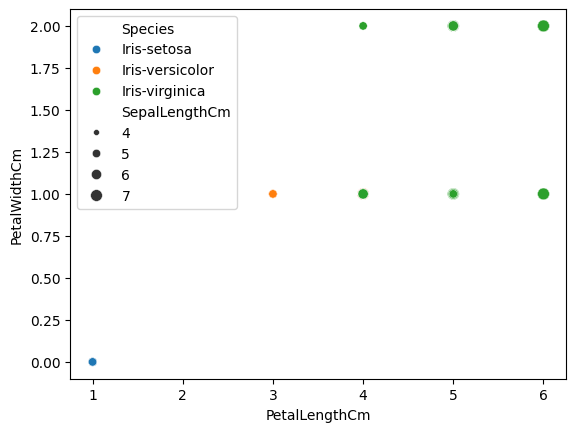

In [30]:
sns.scatterplot(
    x=df["PetalLengthCm"],
    y=df["PetalWidthCm"],
    hue=df["Species"],
    size=df["SepalLengthCm"]
)

plt.show()

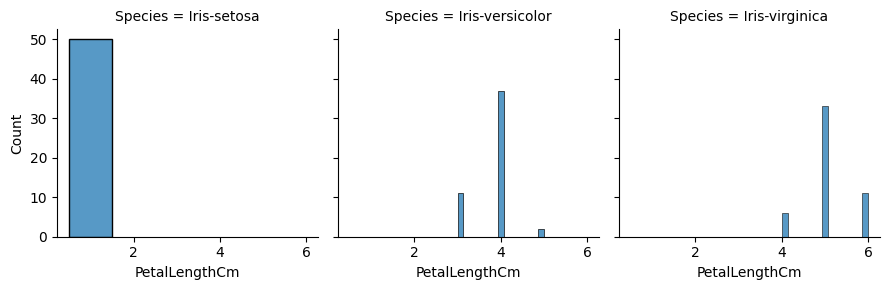

In [31]:
g = sns.FacetGrid(
    df,
    col="Species"
)

g.map(
    sns.histplot,
    "PetalLengthCm"
)

plt.show()